---


# Part 1 - studying the effect of model loading and freezing

In [1]:
import os
current_wd = os.getcwd()
print("Current working directory:", current_wd)

training="long"
# training="short"

Current working directory: /pdo/users/pablomer


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
# Part 2
# 1) Load your results
if training == "long":
    df1 = pd.read_csv("mnt/tess/models/vetting/20250501/cshallue_optuna_20250501/optuna_trials_50.csv")  # or the path to your spreadsheet
    df2 = pd.read_csv("mnt/tess/models/vetting/20250429/cshallue_optuna_20250429/optuna_trials.csv")  # or the path to your spreadsheet
    # df3 = pd.read_csv("mnt/tess/models/vetting/20250501/cshallue_optuna_20250501/optuna_trials.csv")  # or the path to your spreadsheet
    # combined = pd.concat([df1, df2, df3])
    combined= pd.concat([df1, df2])
elif training == "short":
    df1 = pd.read_csv("mnt/tess/models/vetting/20250501/cshallue_optuna_20250501_shortertrain/optuna_trials.csv")
    combined = df1


In [3]:
combined.shape

(100, 10)

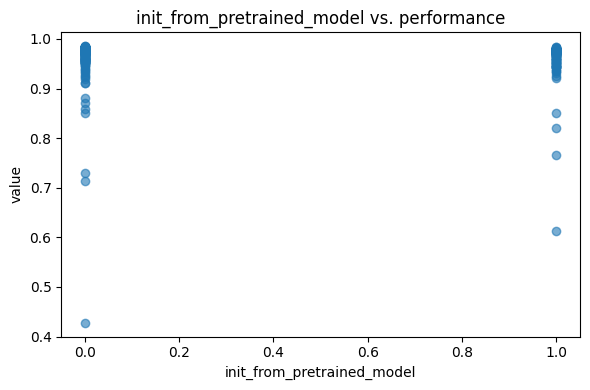

In [14]:
# Plot X axis: init from pretrained model, Y axis: value
plt.figure(figsize=(6,4))
plt.scatter(combined['init_from_pretrained_model'], combined['value'], alpha=0.6)
plt.xlabel('init_from_pretrained_model')
plt.ylabel('value')
plt.title("init_from_pretrained_model vs. performance")
plt.tight_layout()
plt.show()
# Plot X axis: freeze pretrained params, in the cases where init_from_pretrained_model=True, Y axis: value
# plt.figure(figsize=(6,4))

#Plot X axis: freeze pretrained params, in the cases where init_from_pretrained_model=False, Y axis: value (for sanity check)


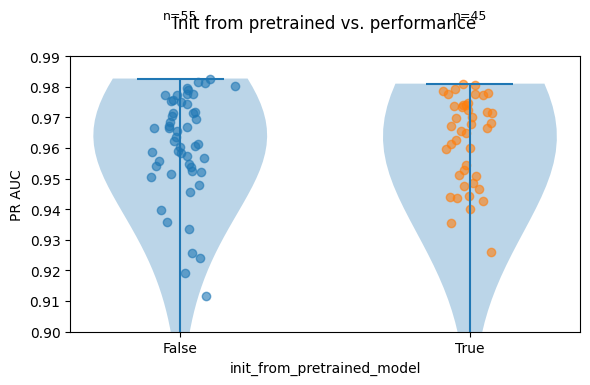

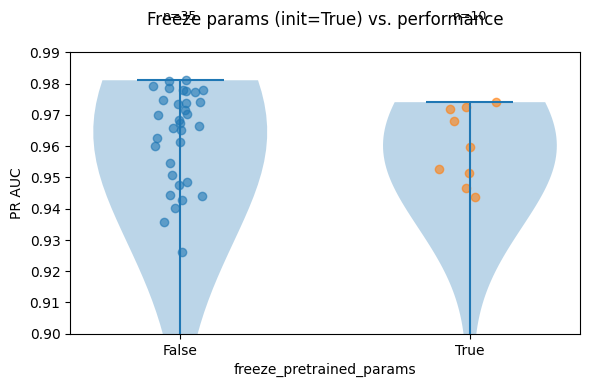

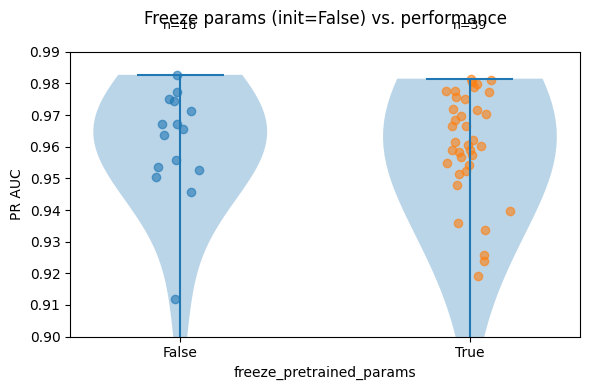

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_boolean_vs_value(df, x_col, y_col='value', title='', jitter_width=0.05):
    """
    Scatter + violin overlaid for a boolean x-axis column vs. a numeric y-axis column.
    Annotates the count of points above and the best value below each category.
    """
    categories = [False, True]
    data = [df[df[x_col] == cat][y_col].values for cat in categories]
    counts = [len(vals) for vals in data]

    # Prepare figure
    fig, ax = plt.subplots(figsize=(6, 4))

    # 1) Violin plot
    ax.violinplot(data, positions=[0, 1], widths=0.6)

    # 2) Scatter with jitter
    for pos, vals in zip([0, 1], data):
        x_jitter = np.random.normal(loc=pos, scale=jitter_width, size=len(vals))
        ax.scatter(x_jitter, vals, alpha=0.6)

    # 3) Compute y-range and offsets
    all_vals = np.concatenate(data) if any(len(vals) > 0 for vals in data) else np.array([0])
    y_max = all_vals.max()
    y_min = all_vals.min()
    offset = (y_max - y_min) * 0.05 if y_max != y_min else 0.05

    # 4) Annotate counts above each category
    for pos, count in zip([0, 1], counts):
        ax.text(pos, y_max + offset, f'n={count}', ha='center', va='bottom', fontsize=9)

    # 5) Annotate best value below each category
    for pos, vals in zip([0, 1], data):
        if len(vals) > 0:
            best_val = vals.max()
            # ax.text(pos, y_min - offset * 4,
                    # f'best: {best_val:.3f}',
                    # ha='center', va='top', fontsize=9, fontweight='bold')

    # 6) Adjust y-limits to fit annotations
    ax.set_ylim(y_min - offset * 2, y_max + offset * 3)

    # 7) Labels, ticks, and title
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['False', 'True'])
    ax.set_xlabel(x_col)
    ax.set_ylabel('PR AUC')
    ax.set_ylim(0.9,0.99)
    ax.set_title(title, pad=20)

    plt.tight_layout()
    plt.show()


# Usage Example (if `combined` exists):
plot_boolean_vs_value(combined, 'init_from_pretrained_model', title='Init from pretrained vs. performance')
df_init_true = combined[combined['init_from_pretrained_model']]
plot_boolean_vs_value(df_init_true, 'freeze_pretrained_params', title='Freeze params (init=True) vs. performance')
df_init_false = combined[~combined['init_from_pretrained_model']]
plot_boolean_vs_value(df_init_false, 'freeze_pretrained_params', title='Freeze params (init=False) vs. performance')


---


# Part 2 - Other analysis

In [ ]:
import os
current_wd = os.getcwd()
print("Current working directory:", current_wd)

Current working directory: /pdo/users/pablomer


Top 10 trials:
    trial_number     value  learning_rate  weight_decay  \
17            17  0.982717       0.000530      0.008909   
22            22  0.981051       0.000462      0.017171   
23            23  0.980745       0.000610      0.025187   
19            19  0.979308       0.001947      0.014788   
24            24  0.978541       0.000662      0.001740   
30            30  0.978085       0.000168      0.000097   
4              4  0.977793       0.000299      0.010736   
40            40  0.977718       0.001270      0.049740   
45            45  0.977511       0.000443      0.015117   
21            21  0.977384       0.001780      0.015007   

    pre_logits_dropout_rate  
17                 0.245495  
22                 0.238066  
23                 0.237735  
19                 0.123010  
24                 0.235676  
30                 0.415349  
4                  0.120016  
40                 0.369011  
45                 0.262855  
21                 0.129964  

Corr

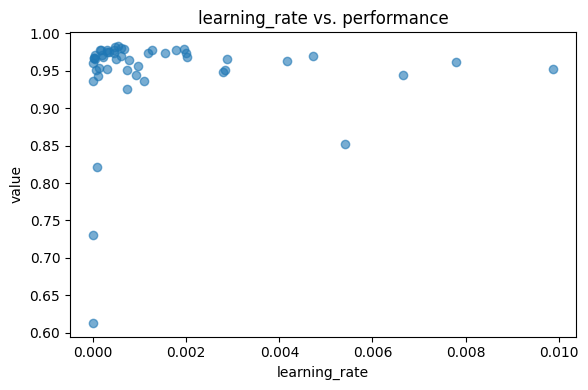

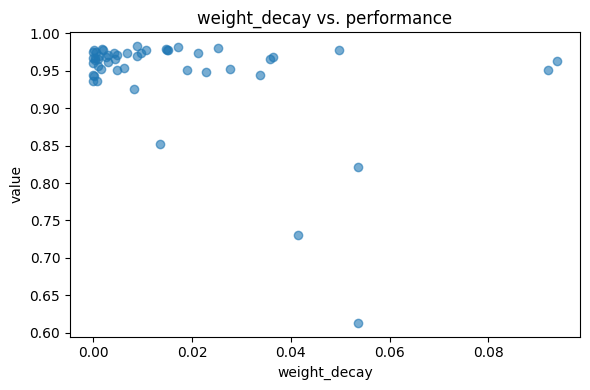

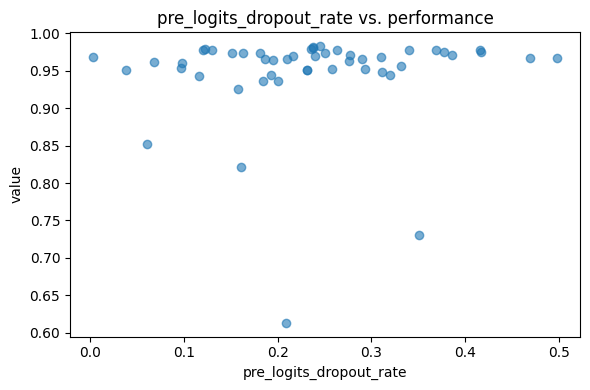

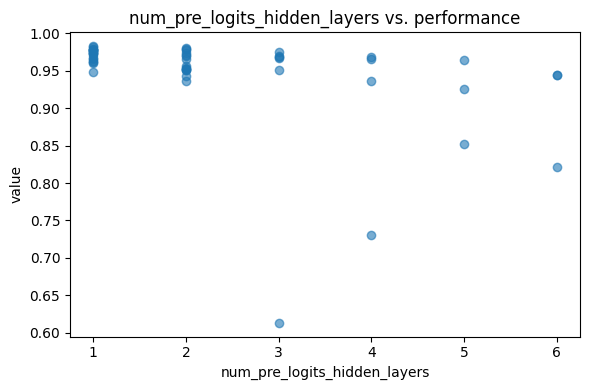

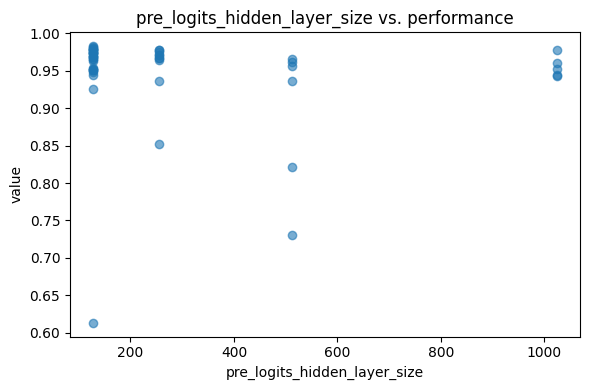

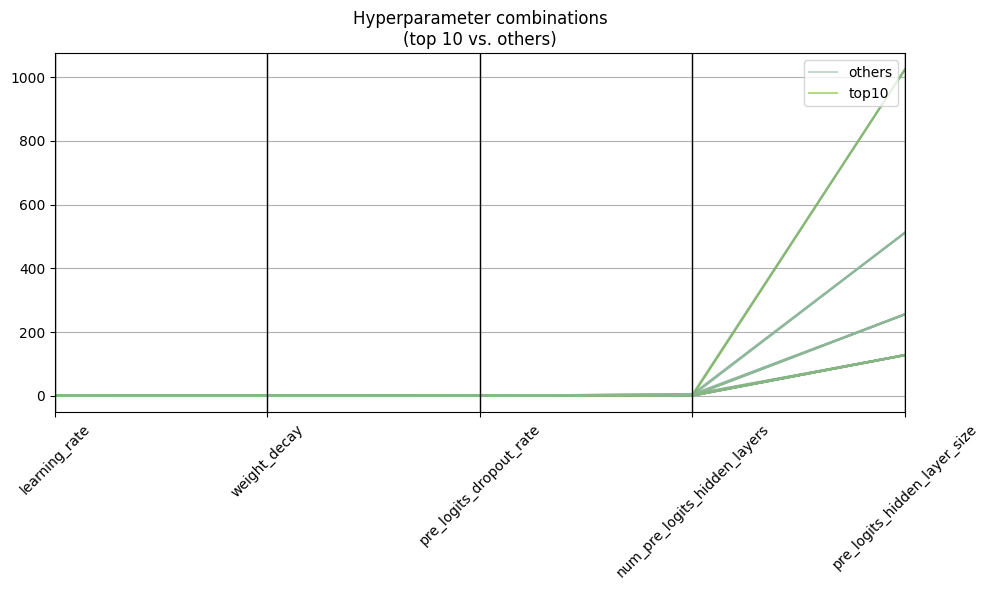

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# 1) Load your results
df = pd.read_csv("mnt/tess/models/vetting/20250501/cshallue_optuna_20250501/optuna_trials.csv")  # or the path to your spreadsheet

# 2) Quick overview
# print(df.describe())                 # summary stats for all numeric columns
# print(df['state'].value_counts())    # how many COMPLETE vs other states

# 3) Best trials
top_n = df.sort_values('value', ascending=False).head(10)
print("Top 10 trials:")
print(top_n[['trial_number', 'value',
             'learning_rate','weight_decay',
             'pre_logits_dropout_rate']])

# 4) Correlation analysis
#    (only numeric hyperparams + the objective)
num_cols = ['value', 'learning_rate', 'weight_decay',
            'pre_logits_dropout_rate', 'num_pre_logits_hidden_layers',
            'pre_logits_hidden_layer_size']
corr = df[num_cols].corr()['value'].sort_values(ascending=False)
print("\nCorrelation with objective:")
print(corr)

# 5) Scatter plots
for param in num_cols[1:]:
    plt.figure(figsize=(6,4))
    plt.scatter(df[param], df['value'], alpha=0.6)
    plt.xlabel(param)
    plt.ylabel('value')
    plt.title(f"{param} vs. performance")
    plt.tight_layout()
    plt.show()

# 6) Parallel-coordinates plot
#    convert booleans to ints so they can be plotted
df_plot = df.copy()
df_plot['init_from_pretrained_model'] = df_plot['init_from_pretrained_model'].astype(int)
df_plot['freeze_pretrained_params']   = df_plot['freeze_pretrained_params'].astype(int)

# mark the top 10 trials
df_plot['best10'] = df_plot['trial_number'].isin(top_n['trial_number']).map({True:'top10', False:'others'})

plt.figure(figsize=(10,6))
parallel_coordinates(
    df_plot[['best10'] + num_cols[1:]],
    class_column='best10',
    alpha=0.5
)
plt.title("Hyperparameter combinations\n(top 10 vs. others)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7) (Optional) If you originally used Optuna:
#    from optuna.importance import get_param_importances
#    study = optuna.load_study(study_name="your_study", storage="sqlite:///db.sqlite3")
#    imp = get_param_importances(study)
#    print("Optuna hyperparameter importances:", imp)


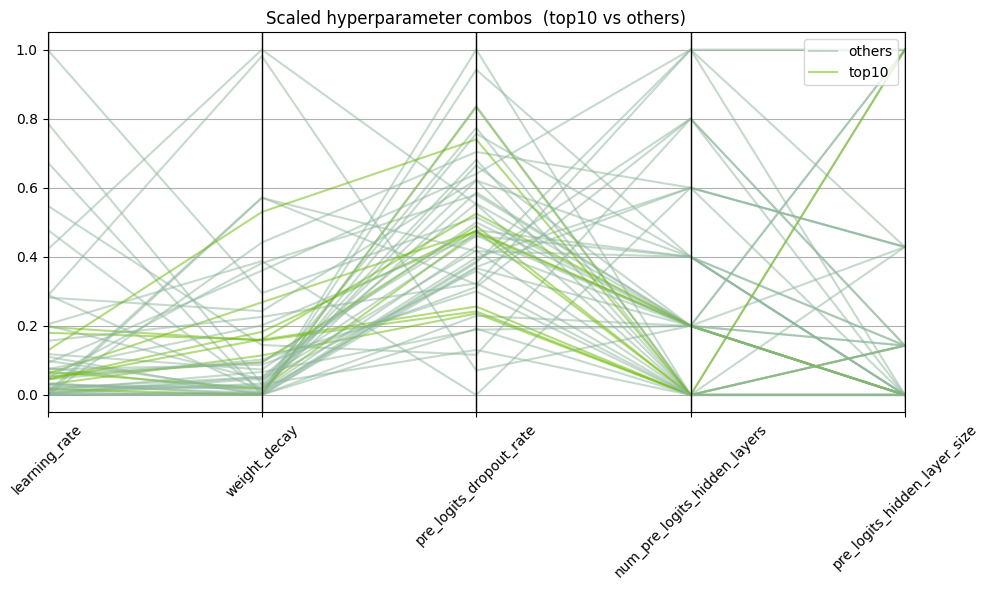

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# assume `df_plot` and `top_n` are defined as before, and
# num_cols = ['value', 'learning_rate', 'weight_decay',
#             'pre_logits_dropout_rate', 'num_pre_logits_hidden_layers',
#             'pre_logits_hidden_layer_size']

# 1) Select only the hyperparam columns (exclude 'value' if you like)
features = num_cols[1:]  # all but 'value'

# 2) Min–max scale each feature to [0,1]
scaler = MinMaxScaler()
df_scaled = df_plot.copy()
df_scaled[features] = scaler.fit_transform(df_scaled[features])

# 3) Mark the top-10 as before
df_scaled['best10'] = df_scaled['trial_number'].isin(top_n['trial_number']) \
                      .map({True:'top10', False:'others'})

# 4) Plot
plt.figure(figsize=(10,6))
parallel_coordinates(
    df_scaled[['best10'] + features],
    class_column='best10',
    alpha=0.5
)
plt.title("Scaled hyperparameter combos  (top10 vs others)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


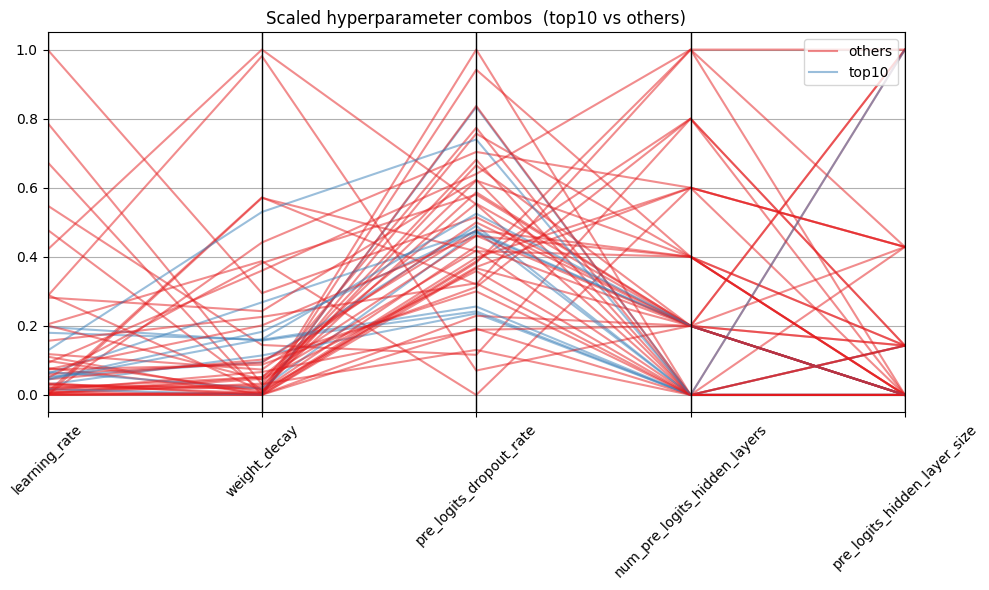

In [ ]:
from matplotlib import pyplot as plt
from pandas.plotting import parallel_coordinates

# pick two very distinct colors
colors = ['#e41a1c',  # red for top10
          '#377eb8']  # blue for others

plt.figure(figsize=(10,6))
parallel_coordinates(
    df_scaled[['best10'] + features],
    class_column='best10',
    color=colors,
    alpha=0.5
)
plt.title("Scaled hyperparameter combos  (top10 vs others)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
